In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1691s 10us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


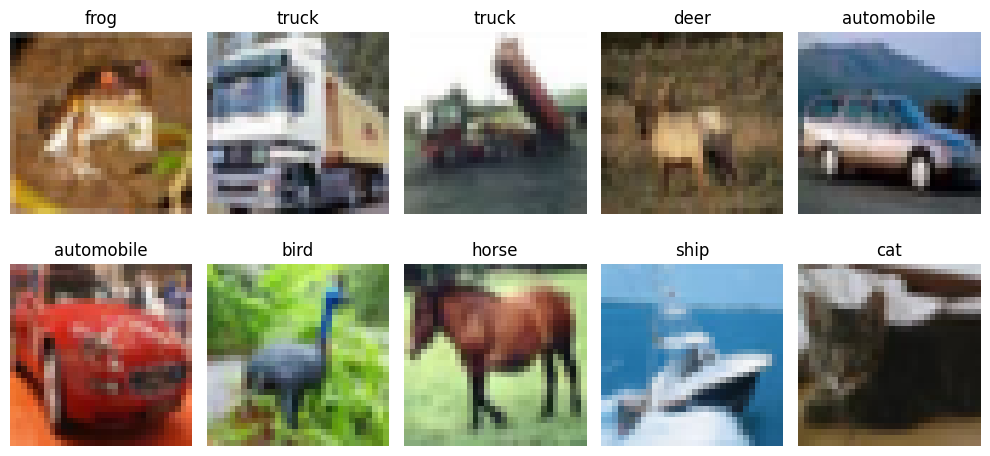

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[ann_early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.2395 - loss: 2.0421 - val_accuracy: 0.3194 - val_loss: 1.9204
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.2901 - loss: 1.9149 - val_accuracy: 0.3510 - val_loss: 1.8406
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3086 - loss: 1.8765 - val_accuracy: 0.3422 - val_loss: 1.8342
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3199 - loss: 1.8518 - val_accuracy: 0.3458 - val_loss: 1.8148
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3299 - loss: 1.8324 - val_accuracy: 0.3676 - val_loss: 1.8048
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3422 - loss: 1.8118 - val_accuracy: 0.3718 - val_loss: 1.7813
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3482 - loss: 1.7927 - val_accuracy: 0.3782 - val_loss: 1.7586
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3496 - loss: 1.7871 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4175 - loss: 1.6550
ANN Test Accuracy: 0.41749998927116394


In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[cnn_early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 129ms/step - accuracy: 0.4477 - loss: 1.5355 - val_accuracy: 0.4314 - val_loss: 1.5884
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 131ms/step - accuracy: 0.5916 - loss: 1.1655 - val_accuracy: 0.6148 - val_loss: 1.0863
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 123ms/step - accuracy: 0.6586 - loss: 0.9845 - val_accuracy: 0.5976 - val_loss: 1.1458
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.6989 - loss: 0.8608 - val_accuracy: 0.6634 - val_loss: 0.9948
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 125ms/step - accuracy: 0.7360 - loss: 0.7634 - val_accuracy: 0.6928 - val_loss: 0.9043
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 124ms/step - accuracy: 0.7546 - loss: 0.6917 - val_accuracy: 0.7098 - val_loss: 0.8484
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.7829 - loss: 0.6171 - val_accuracy: 0.7000 - val_loss: 0.9074
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 126ms/step - accuracy: 0.8063 - l

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7080 - loss: 0.8594
CNN Test Accuracy: 0.7080000042915344


In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
aug_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 105ms/step - accuracy: 0.3577 - loss: 1.7459 - val_accuracy: 0.4532 - val_loss: 1.5257
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.4667 - loss: 1.4768 - val_accuracy: 0.5260 - val_loss: 1.3176
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.5112 - loss: 1.3657 - val_accuracy: 0.5818 - val_loss: 1.1649
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.5452 - loss: 1.2852 - val_accuracy: 0.5916 - val_loss: 1.1596
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.5670 - loss: 1.2264 - val_accuracy: 0.6334 - val_loss: 1.0246
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.5884 - loss: 1.1746 - val_accuracy: 0.6240 - val_loss: 1.1068
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.6036 - loss: 1.1335 - val_accuracy: 0.6550 - val_loss: 0.9830
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 103ms/step - accuracy: 0.6157 - loss: 1

In [11]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6943 - loss: 0.8821
Augmented CNN Test Accuracy: 0.6942999958992004


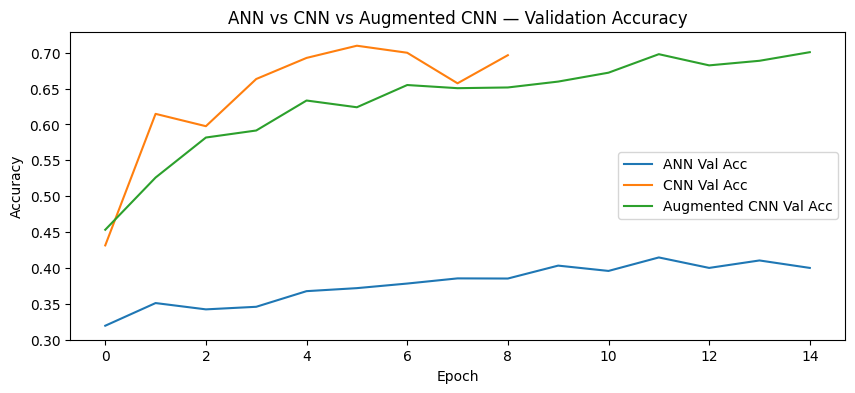

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN vs Augmented CNN — Validation Accuracy")
plt.legend()
plt.show()

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4175
1,CNN,0.7080
2,Augmented CNN,0.6943
